
# Clean EMPCA (K-alpha) Frequency-Domain Training: Paper-Ready Validation

This notebook upgrades the EMPCA study to a publication-oriented, reproducible workflow with clear separation of method, verification, and interpretation.

## Method Statement

We model traces $x_i(t)$ and transform to frequency domain
$$
X_i(f)=\mathcal{F}[x_i(t)].
$$

EMPCA is trained in a weighted metric
$$
\|X\|_W^2 = \sum_f W(f)\,|X(f)|^2,\qquad W(f)=rac{1}{J(f)}
$$
where $J(f)$ is the noise PSD.

Equivalent whitening form:
$$
	ilde X_i(f)=rac{X_i(f)}{\sqrt{J(f)}}
$$
and standard PCA is performed on $	ilde X_i(f)$.

If training is **uncentered**, the first component tends toward the dominant **mean direction** of the signal ensemble.



## Derivation Notes

### 1) Why uncentered PC1 can resemble mean/template
For uncentered PCA on signal-dominated pulse families,
$$
x_i(t)pprox A_i s(t-\delta t_i),
$$
so for small timing spread,
$$
\mathbb{E}[x(t)]pprox ar A\, s(t).
$$
Hence the leading direction aligns with the empirical mean pulse shape.

### 2) Why PC2 is expected to be timing-like
First-order expansion:
$$
s(t-\delta t)pprox s(t)-\delta t\,s'(t).
$$
Timing jitter therefore introduces variation in the derivative direction $s'(t)$.

### 3) Width perturbation proxy
Define $s_\epsilon(t)=s((1+\epsilon)t)$. Then
$$
\left.rac{\partial s((1+\epsilon)t)}{\partial \epsilon}ight|_{\epsilon=0}=t\,s'(t),
$$
which gives a physically interpretable width/shape deformation mode.


## Setup

In [1]:

import json
from pathlib import Path

import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

try:
    import pandas as pd
except Exception:
    pd = None

np.set_printoptions(suppress=True, precision=5)

mpl.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "lines.linewidth": 2.0,
    "axes.grid": True,
})


In [2]:

CFG = {
    "pretrigger": 4000,
    "baseline_method": "mean",
    "center_primary": False,
    "max_events": 2500,
    "n_components": 8,
    "eps_psd": 1e-30,
    "rng_seed": 1,
    "run_toy_validation": True,
    "toy_n_events": 1400,
    "width_eps": 0.02,
}

# Paths
CWD = Path.cwd()
ROOT_CANDIDATES = [CWD, CWD.parent, CWD.parent.parent]
if (CWD / "PCA_dev").exists():
    ROOT_CANDIDATES.append(CWD / "PCA_dev")

ROOT = next((p for p in ROOT_CANDIDATES if (p / "wk8").exists() and (p / "reusable").exists()), CWD)
DATA_CANDIDATES = [ROOT / "wk8" / "PC_interpretation", CWD]
DATA_DIR = next((d for d in DATA_CANDIDATES if (d / "k_alpha_traces.h5").exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("Could not locate k_alpha_traces.h5")

TRACE_PATH = DATA_DIR / "k_alpha_traces.h5"
RQS_PATH = DATA_DIR / "k_alpha_rqs.h5"
TEMPLATE_PATH = DATA_DIR / "template_K_alpha_tight.npy"
PSD_PATH = Path('/ceph/dwong/delight/noise_psd_xray.npy')

for p in [TRACE_PATH, TEMPLATE_PATH, PSD_PATH]:
    if not p.exists():
        raise FileNotFoundError(p)

OUT_ROOT = ROOT / "outputs"
FIG_DIR = OUT_ROOT / "figures"
TAB_DIR = OUT_ROOT / "tables"
NB_DIR = OUT_ROOT / "notebook"
for d in [FIG_DIR, TAB_DIR, NB_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("DATA_DIR:", DATA_DIR)
print("Output dirs:", FIG_DIR, TAB_DIR, NB_DIR, sep="\n  ")


ROOT: /home/dwong/DELight_mtr/PCA_dev
DATA_DIR: /home/dwong/DELight_mtr/PCA_dev/wk8/PC_interpretation
Output dirs:
  /home/dwong/DELight_mtr/PCA_dev/outputs/figures
  /home/dwong/DELight_mtr/PCA_dev/outputs/tables
  /home/dwong/DELight_mtr/PCA_dev/outputs/notebook


In [3]:

# Optional EMPCA transform convention from project
TRANSFORM_NAME = "numpy.rfft / numpy.irfft fallback"
ti_rfft = None
ti_irfft = None
try:
    import sys
    empca_dir = ROOT / "reusable" / "EMPCA"
    if empca_dir.exists():
        sys.path.insert(0, str(empca_dir))
        from empca_TCY_optimized import ti_rfft, ti_irfft
        TRANSFORM_NAME = "ti_rfft / ti_irfft (empca_TCY_optimized)"
except Exception:
    pass

print("Transform convention:", TRANSFORM_NAME)


Transform convention: ti_rfft / ti_irfft (empca_TCY_optimized)


## Helpers

In [4]:

def savefig(fig, stem):
    fig.savefig(FIG_DIR / f"{stem}.pdf", bbox_inches="tight")
    fig.savefig(FIG_DIR / f"{stem}.png", bbox_inches="tight")


def baseline_correct_per_trace(X_time, pretrigger=4000, method='mean'):
    X_time = np.asarray(X_time, dtype=np.float64)
    if X_time.ndim != 2:
        raise ValueError(f'Expected 2D [n_events, n_time], got {X_time.shape}')
    pre = X_time[:, :pretrigger]
    if method == 'mean':
        b = np.mean(pre, axis=1, keepdims=True)
    elif method == 'median':
        b = np.median(pre, axis=1, keepdims=True)
    else:
        raise ValueError("method must be 'mean' or 'median'")
    return X_time - b


def to_freq(X_time):
    X_time = np.asarray(X_time)
    if X_time.ndim == 1:
        X_time = X_time[None, :]
    return np.atleast_2d(ti_rfft(X_time)) if ti_rfft is not None else np.fft.rfft(X_time, axis=1)


def to_time(Xf, n_time=None):
    Xf = np.asarray(Xf)
    if Xf.ndim == 1:
        Xf = Xf[None, :]
    if ti_irfft is not None:
        Xt = np.atleast_2d(ti_irfft(Xf))
        return Xt[:, :n_time] if n_time is not None else Xt
    return np.fft.irfft(Xf, n=n_time, axis=1)


def maybe_match_psd_length(arr, target_len):
    arr = np.asarray(arr)
    vecs = []
    if arr.ndim == 1:
        vecs = [arr]
    elif arr.ndim == 2:
        if 1 in arr.shape:
            vecs.append(arr.reshape(-1))
        vecs.extend([arr[i, :] for i in range(arr.shape[0])])
        vecs.extend([arr[:, j] for j in range(arr.shape[1])])
    else:
        vecs = [arr.reshape(-1)]

    for v in vecs:
        n = len(v)
        if n == target_len:
            return np.asarray(v, dtype=np.float64)
        if n in (2 * target_len - 2, 2 * target_len):
            return np.asarray(v[:target_len], dtype=np.float64)
    return None


def weighted_inner(u, v, w):
    return np.vdot(u, w * v)


def weighted_norm(u, w):
    return float(np.sqrt(max(np.real(weighted_inner(u, u, w)), 0.0)))


def normalize_weighted(u, w):
    n = weighted_norm(u, w)
    return u.copy() if n == 0 else u / n


def weighted_cosine(u, v, w):
    den = weighted_norm(u, w) * weighted_norm(v, w)
    return np.nan if den == 0 else float(np.abs(weighted_inner(u, v, w)) / den)


def time_cosine(u_t, v_t):
    u_t = np.asarray(u_t, dtype=float)
    v_t = np.asarray(v_t, dtype=float)
    den = np.linalg.norm(u_t) * np.linalg.norm(v_t)
    return np.nan if den == 0 else float(np.dot(u_t, v_t) / den)


def principal_angle_deg(u, v, w):
    c = np.clip(weighted_cosine(u, v, w), -1.0, 1.0)
    return float(np.degrees(np.arccos(c)))


def best_fit_alpha(u, v, w):
    den = weighted_inner(v, v, w)
    return 0.0 + 0.0j if np.abs(den) < 1e-30 else weighted_inner(v, u, w) / den


def sign_align_to_ref(u, ref, w):
    return -u if np.real(weighted_inner(u, ref, w)) < 0 else u


def weighted_project_coeff(X, U, w):
    C = np.zeros((X.shape[0], U.shape[0]), dtype=np.complex128)
    for j in range(U.shape[0]):
        den = weighted_inner(U[j], U[j], w)
        C[:, j] = np.array([weighted_inner(U[j], x, w) for x in X]) / den
    return C


def train_clean_empca_weighted(Xf, w, n_components=3, center=False):
    sqrtW = np.sqrt(w)
    Xw = Xf * sqrtW[None, :]
    muw = np.mean(Xw, axis=0, keepdims=True) if center else np.zeros((1, Xw.shape[1]), dtype=Xw.dtype)
    Xw_fit = Xw - muw

    _, S, Vh = np.linalg.svd(Xw_fit, full_matrices=False)
    k = min(n_components, Vh.shape[0])
    pcs_w = Vh[:k].copy()

    pcs_f = np.asarray([normalize_weighted(p / sqrtW, w) for p in pcs_w])
    coeff = weighted_project_coeff(Xf, pcs_f, w)
    return {"pcs_w": pcs_w, "pcs_f": pcs_f, "S": S, "coeff": coeff, "muw": muw, "Xw_fit": Xw_fit}


def weighted_rel_residuals(X, R, w):
    rr = []
    for x, r in zip(X, R):
        den = max(weighted_norm(x, w), 1e-30)
        rr.append(weighted_norm(x - r, w) / den)
    return np.asarray(rr)


def pearsonr_np(x, y):
    m = np.isfinite(x) & np.isfinite(y)
    if np.sum(m) < 3:
        return np.nan
    return float(np.corrcoef(x[m], y[m])[0, 1])


def spearmanr_np(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    m = np.isfinite(x) & np.isfinite(y)
    if np.sum(m) < 3:
        return np.nan
    xr = np.argsort(np.argsort(x[m]))
    yr = np.argsort(np.argsort(y[m]))
    return float(np.corrcoef(xr, yr)[0, 1])


def linear_fit_metrics(x, y):
    m = np.isfinite(x) & np.isfinite(y)
    if np.sum(m) < 3:
        return {"slope": np.nan, "intercept": np.nan, "r2": np.nan}
    slope, intercept = np.polyfit(x[m], y[m], 1)
    yhat = slope * x[m] + intercept
    ss_res = np.sum((y[m] - yhat) ** 2)
    ss_tot = np.sum((y[m] - np.mean(y[m])) ** 2)
    r2 = np.nan if ss_tot <= 0 else 1.0 - ss_res / ss_tot
    return {"slope": float(slope), "intercept": float(intercept), "r2": float(r2)}


def normalize_time(v):
    n = np.linalg.norm(v)
    return v.copy() if n == 0 else v / n


def deform_stretch(x, factor):
    n = len(x)
    t = np.arange(n)
    t0 = t - (n - 1) / 2
    ts = t0 / factor + (n - 1) / 2
    return np.interp(t, ts, x, left=x[0], right=x[-1])


## Section A - Data And Preprocessing

In [5]:

with h5py.File(TRACE_PATH, 'r') as f:
    X_time_raw = np.asarray(f['traces'][:], dtype=np.float64)

rqs = None
if RQS_PATH.exists():
    with h5py.File(RQS_PATH, 'r') as f:
        if 'rqs' in f:
            rqs = f['rqs'][:]

if CFG['max_events'] is not None:
    X_time_raw = X_time_raw[:CFG['max_events']]
    if rqs is not None:
        rqs = rqs[:CFG['max_events']]

X_time = baseline_correct_per_trace(X_time_raw, CFG['pretrigger'], CFG['baseline_method'])
Xf = to_freq(X_time)
freq_len = Xf.shape[1]
n_time = X_time.shape[1]

template_t = np.asarray(np.load(TEMPLATE_PATH), dtype=np.float64).reshape(-1)
if template_t.shape[0] != n_time:
    raise ValueError(f"Template length mismatch: {template_t.shape[0]} vs {n_time}")

template_f = to_freq(template_t)[0]
psd = maybe_match_psd_length(np.load(PSD_PATH, allow_pickle=True), freq_len)
if psd is None:
    raise ValueError(f"PSD length mismatch for freq_len={freq_len}")
psd = np.maximum(psd, CFG['eps_psd'])
w_psd = 1.0 / psd

mean_time = np.mean(X_time, axis=0)
mean_f = np.mean(Xf, axis=0)

print('n_events, n_time, n_freq =', X_time.shape[0], n_time, freq_len)
print('RQS available =', rqs is not None)
if rqs is not None and rqs.dtype.names:
    print('RQS fields:', rqs.dtype.names)


n_events, n_time, n_freq = 2500 32768 16385
RQS available = True
RQS fields: ('time', 'channel', 'trace_index', 'temperature', 'mean_baseline', 'std_baseline', 'mean', 'std', 'A', 'rise_time', 'TF_ampl', 'TF_chi2', 'TF_baseline', 'baseline_slope', 'baseline_offset', 'time_shift', 'OF_ampl_0', 'OF_chi2_0', 'OF_time_0', 'OF_ampl_1', 'OF_chi2_1', 'OF_time_1', 'pc1', 'pc2', 'pca_amp')


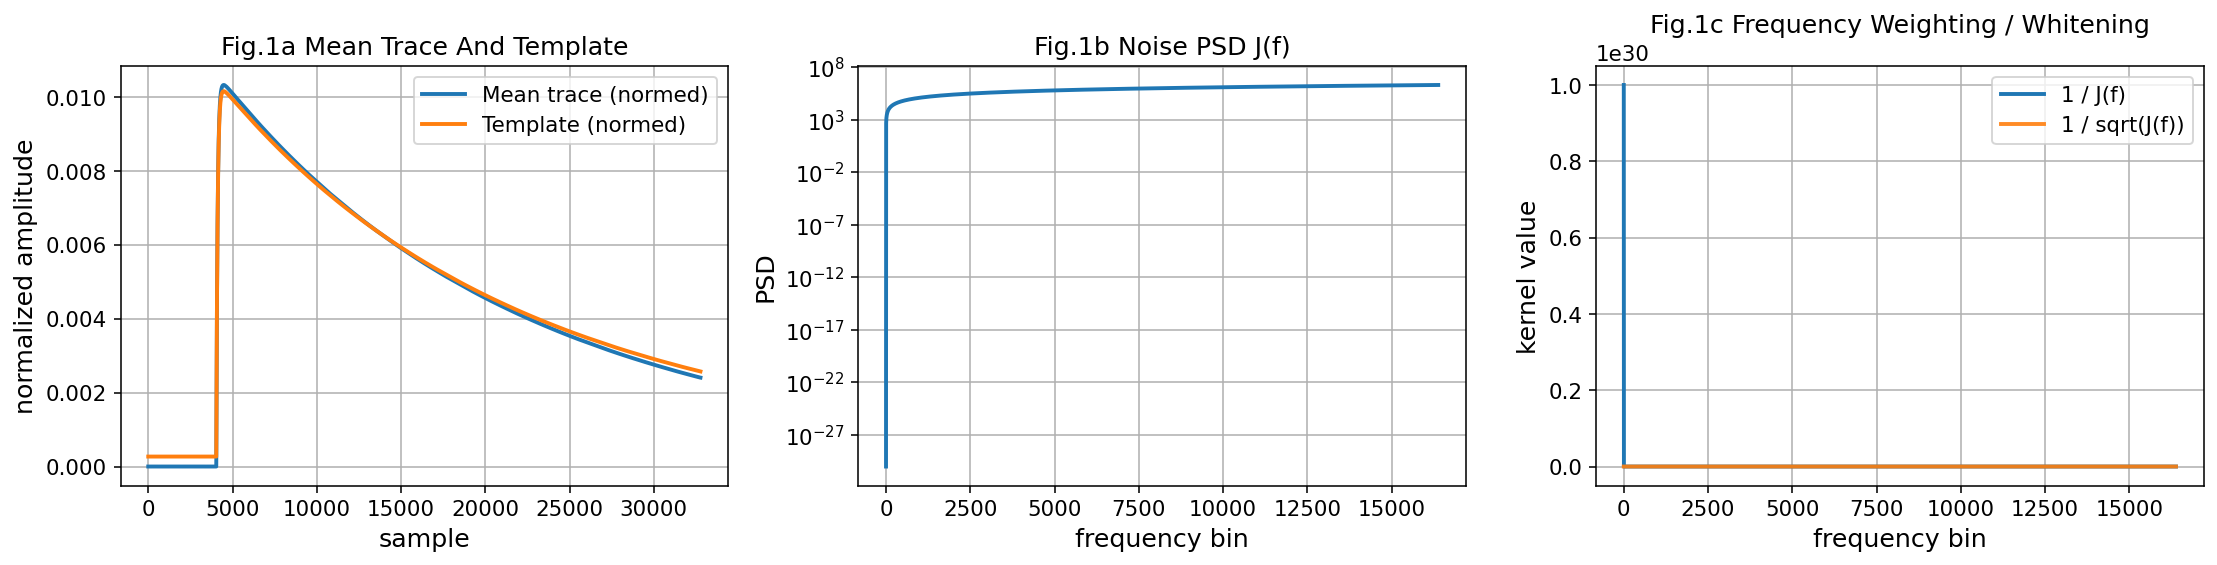

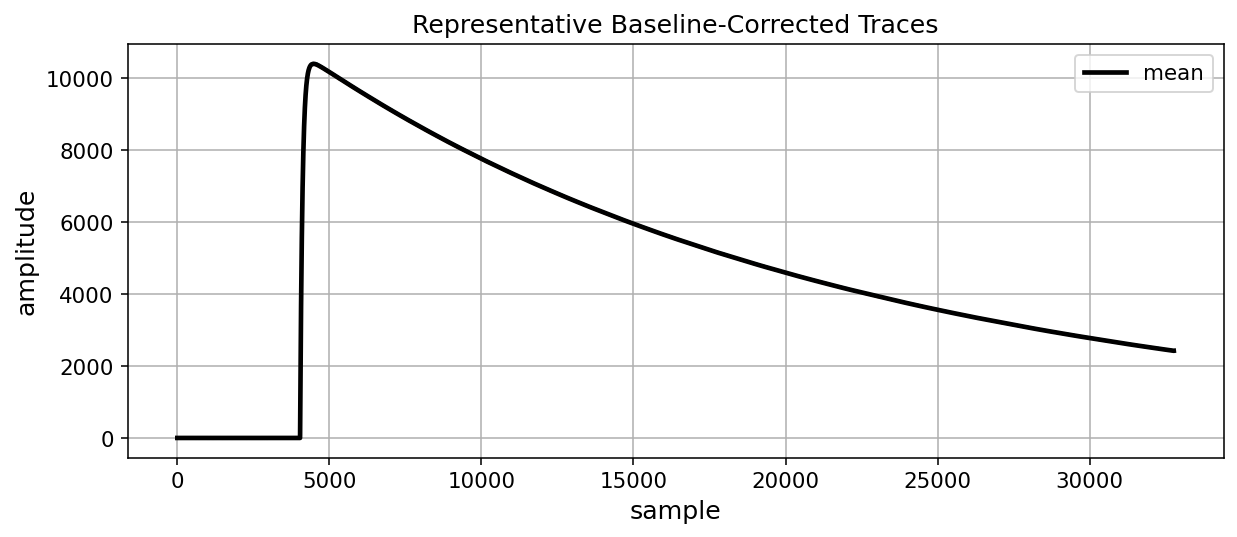

In [6]:

# Figure 1: training ingredients (mean/template, PSD, weighting)
time_axis = np.arange(n_time)
freq_axis = np.arange(freq_len)

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))

ax[0].plot(time_axis, normalize_time(mean_time), label='Mean trace (normed)')
ax[0].plot(time_axis, normalize_time(template_t), label='Template (normed)')
ax[0].set_title('Fig.1a Mean Trace And Template')
ax[0].set_xlabel('sample')
ax[0].set_ylabel('normalized amplitude')
ax[0].legend()

ax[1].plot(freq_axis, psd)
ax[1].set_yscale('log')
ax[1].set_title('Fig.1b Noise PSD J(f)')
ax[1].set_xlabel('frequency bin')
ax[1].set_ylabel('PSD')

ax[2].plot(freq_axis, w_psd, label='1 / J(f)')
ax[2].plot(freq_axis, np.sqrt(w_psd), label='1 / sqrt(J(f))', alpha=0.9)
ax[2].set_title('Fig.1c Frequency Weighting / Whitening')
ax[2].set_xlabel('frequency bin')
ax[2].set_ylabel('kernel value')
ax[2].legend()

fig.tight_layout()
savefig(fig, 'fig01_mean_template_psd')
plt.show()

# representative raw traces
fig, ax = plt.subplots(figsize=(9, 4))
for i in np.linspace(0, min(len(X_time) - 1, 120), 12, dtype=int):
    ax.plot(X_time[i], alpha=0.55, lw=1.1)
ax.plot(mean_time, color='k', lw=2.4, label='mean')
ax.set_title('Representative Baseline-Corrected Traces')
ax.set_xlabel('sample')
ax.set_ylabel('amplitude')
ax.legend()
fig.tight_layout()
savefig(fig, 'fig01b_representative_traces')
plt.show()


## Section B - EMPCA Training Definition

In [7]:

settings = {
    'transform': TRANSFORM_NAME,
    'domain': 'time traces transformed to frequency domain',
    'representation': 'complex rFFT bins',
    'weighting': 'W(f)=1/PSD(f)',
    'whitening': 'Xw = Xf * sqrt(W)',
    'center_primary': CFG['center_primary'],
    'normalization': 'weighted norm enforced for basis vectors in physical frequency space',
    'n_components_requested': CFG['n_components'],
    'n_events': int(X_time.shape[0]),
    'n_time': int(n_time),
    'n_freq': int(freq_len),
}
print(json.dumps(settings, indent=2))


{
  "transform": "ti_rfft / ti_irfft (empca_TCY_optimized)",
  "domain": "time traces transformed to frequency domain",
  "representation": "complex rFFT bins",
  "weighting": "W(f)=1/PSD(f)",
  "whitening": "Xw = Xf * sqrt(W)",
  "center_primary": false,
  "normalization": "weighted norm enforced for basis vectors in physical frequency space",
  "n_components_requested": 8,
  "n_events": 2500,
  "n_time": 32768,
  "n_freq": 16385
}


In [8]:

res_unc = train_clean_empca_weighted(Xf, w_psd, n_components=CFG['n_components'], center=False)
res_ctr = train_clean_empca_weighted(Xf, w_psd, n_components=CFG['n_components'], center=True)

pcs_f = res_unc['pcs_f']
coeff = res_unc['coeff']
S = res_unc['S']

pc1_raw, pc2_raw, pc3_raw = pcs_f[0], pcs_f[1], pcs_f[2]

# physically motivated references for sign alignment
mean_f_ref = normalize_weighted(mean_f, w_psd)
deriv_t = np.gradient(mean_time)
deriv_f = normalize_weighted(to_freq(deriv_t)[0], w_psd)

eps = CFG['width_eps']
width_proxy_t = (deform_stretch(mean_time, 1 + eps) - deform_stretch(mean_time, 1 - eps)) / (2 * eps)
width_proxy_f = normalize_weighted(to_freq(width_proxy_t)[0], w_psd)

pc1 = sign_align_to_ref(pc1_raw, mean_f_ref, w_psd)
pc2 = sign_align_to_ref(pc2_raw, deriv_f, w_psd)
pc3 = sign_align_to_ref(pc3_raw, width_proxy_f, w_psd)

# keep coefficient signs consistent with displayed PCs
coeff = coeff.copy()
if np.real(weighted_inner(pc1_raw, mean_f_ref, w_psd)) < 0: coeff[:, 0] *= -1
if np.real(weighted_inner(pc2_raw, deriv_f, w_psd)) < 0: coeff[:, 1] *= -1
if np.real(weighted_inner(pc3_raw, width_proxy_f, w_psd)) < 0: coeff[:, 2] *= -1

print('Top singular values:', np.array2string(S[:8], precision=5))


Top singular values: [7.86829e+24 7.86201e+08 7.86201e+08 7.86201e+08 7.86201e+08 7.86201e+08
 7.86201e+08 7.86201e+08]


## Section C - Main Results: PCs

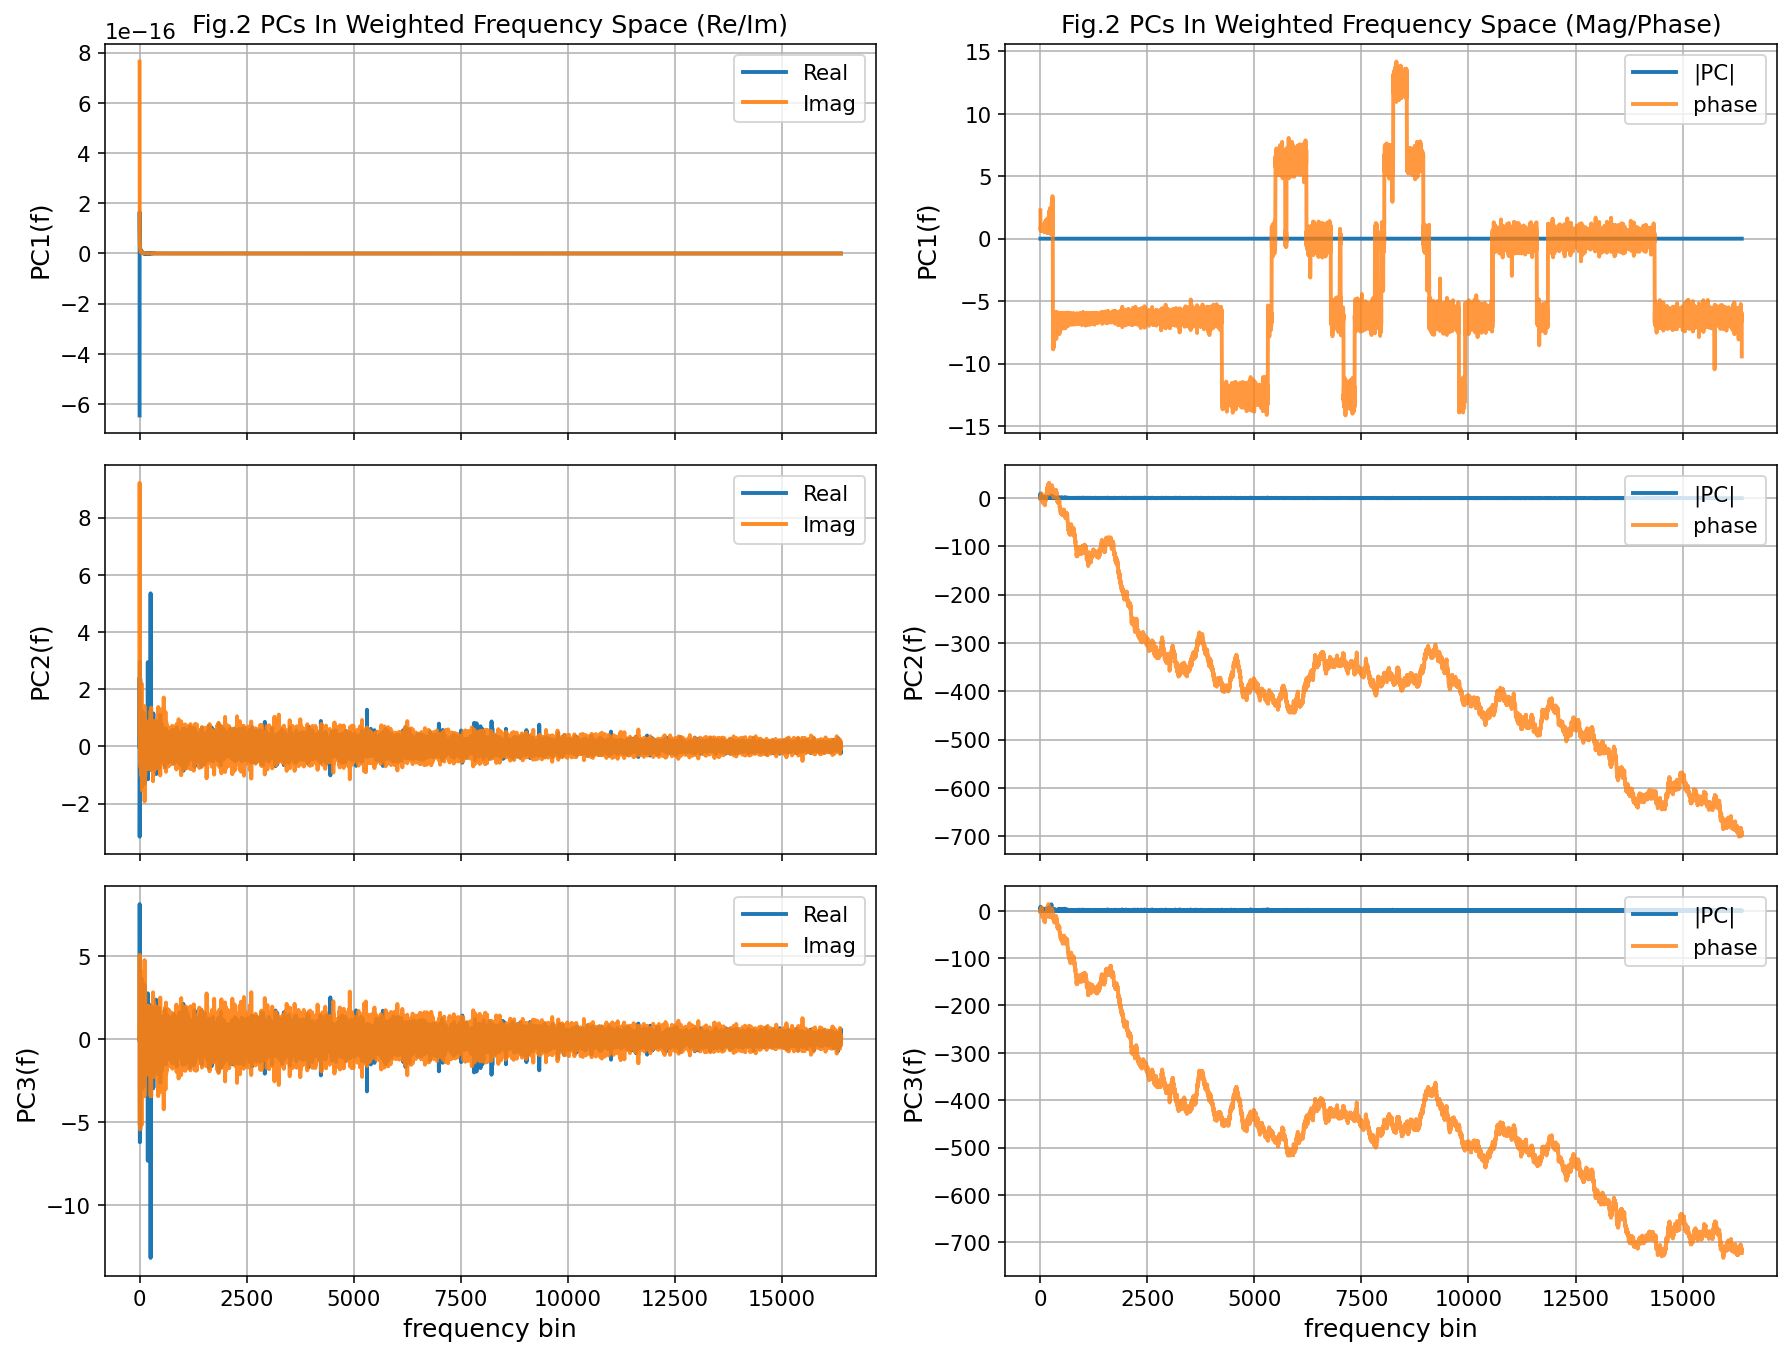

In [9]:

# Figure 2: PCs in frequency domain
fig, ax = plt.subplots(3, 2, figsize=(13, 10), sharex=True)
for i, u in enumerate([pc1, pc2, pc3]):
    ax[i, 0].plot(np.real(u), label='Real')
    ax[i, 0].plot(np.imag(u), label='Imag', alpha=0.9)
    ax[i, 0].set_ylabel(f'PC{i+1}(f)')
    ax[i, 0].legend(loc='upper right')

    ax[i, 1].plot(np.abs(u), label='|PC|')
    ax[i, 1].plot(np.unwrap(np.angle(u)), label='phase', alpha=0.8)
    ax[i, 1].set_ylabel(f'PC{i+1}(f)')
    ax[i, 1].legend(loc='upper right')

ax[0, 0].set_title('Fig.2 PCs In Weighted Frequency Space (Re/Im)')
ax[0, 1].set_title('Fig.2 PCs In Weighted Frequency Space (Mag/Phase)')
ax[2, 0].set_xlabel('frequency bin')
ax[2, 1].set_xlabel('frequency bin')
fig.tight_layout()
savefig(fig, 'fig02_pcs_frequency')
plt.show()


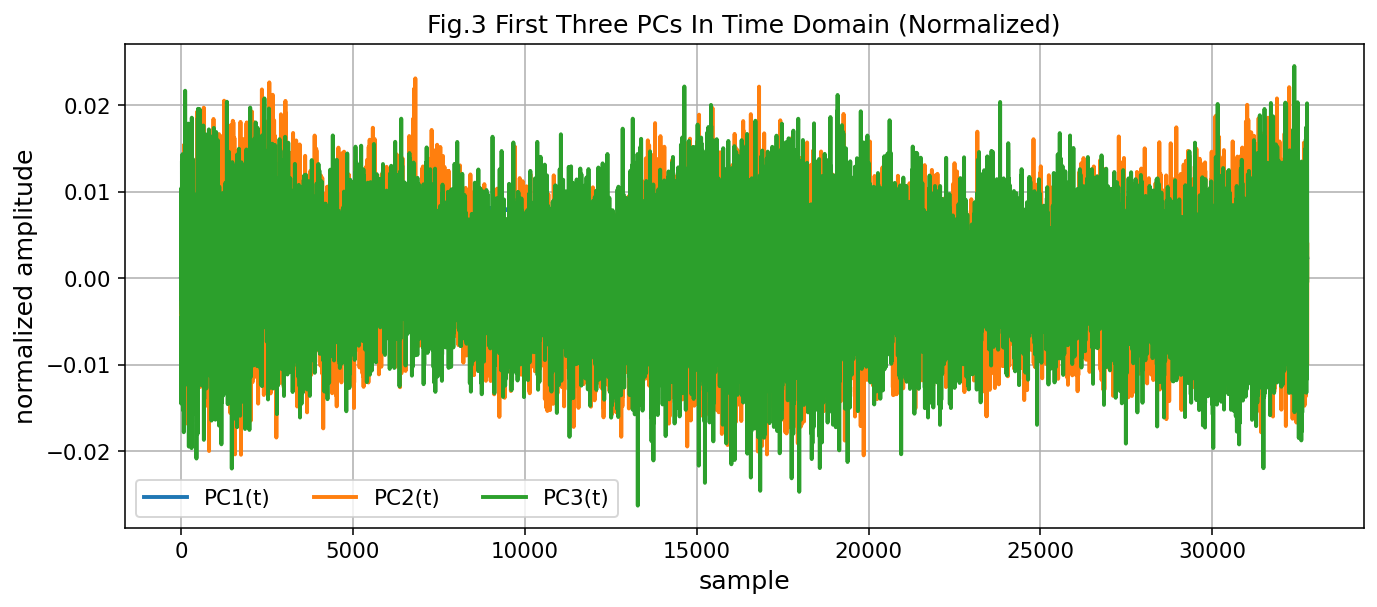

In [10]:

# Figure 3: PCs in time domain
pc1_t = to_time(pc1, n_time=n_time)[0]
pc2_t = to_time(pc2, n_time=n_time)[0]
pc3_t = to_time(pc3, n_time=n_time)[0]

deriv_t_n = normalize_time(deriv_t)
width_t_n = normalize_time(width_proxy_t)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(normalize_time(pc1_t), label='PC1(t)')
ax.plot(normalize_time(pc2_t), label='PC2(t)')
ax.plot(normalize_time(pc3_t), label='PC3(t)')
ax.set_title('Fig.3 First Three PCs In Time Domain (Normalized)')
ax.set_xlabel('sample')
ax.set_ylabel('normalized amplitude')
ax.legend(ncol=3)
fig.tight_layout()
savefig(fig, 'fig03_pcs_time')
plt.show()


## Section D - Quantitative Validation

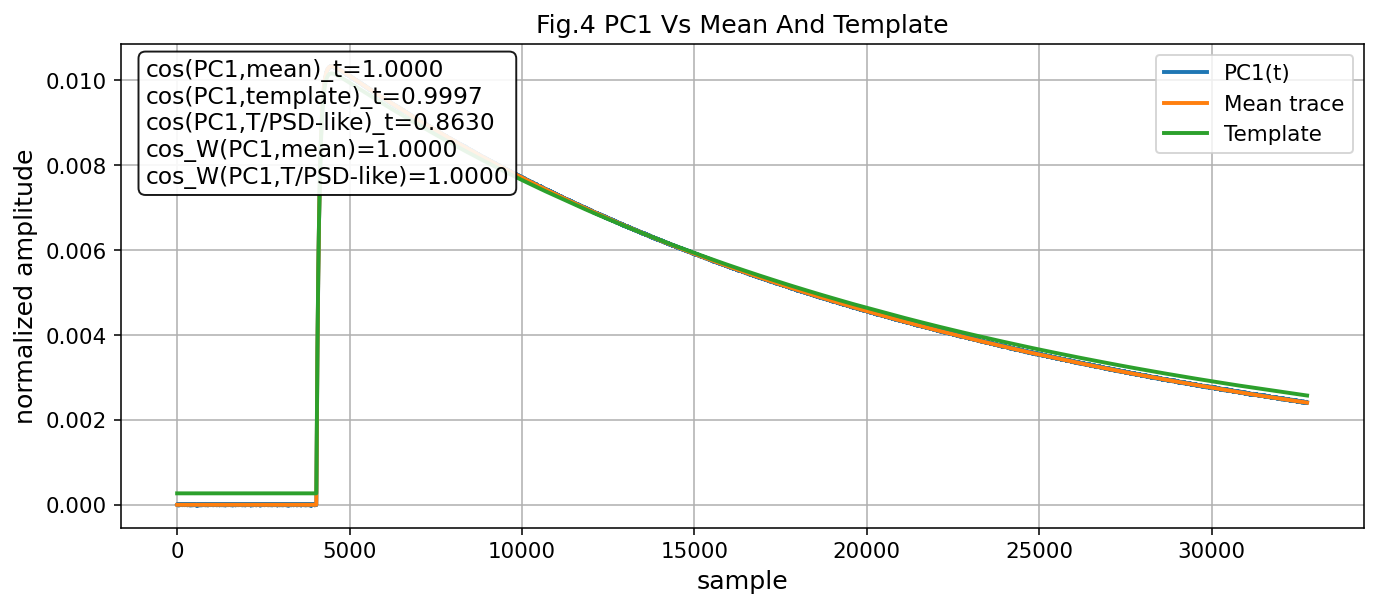

In [11]:
# Figure 4: PC1 vs mean/template and T/PSD-like direction
of_dir = normalize_weighted(template_f / np.maximum(psd, CFG['eps_psd']), w_psd)
of_t = to_time(of_dir, n_time=n_time)[0]

metrics_pc1 = {
    'cos_time_pc1_mean': time_cosine(normalize_time(pc1_t), normalize_time(mean_time)),
    'cos_time_pc1_template': time_cosine(normalize_time(pc1_t), normalize_time(template_t)),
    'cos_time_pc1_of_like': time_cosine(normalize_time(pc1_t), normalize_time(of_t)),
    'cos_w_pc1_mean': weighted_cosine(pc1, mean_f_ref, w_psd),
    'cos_w_pc1_template': weighted_cosine(pc1, normalize_weighted(template_f, w_psd), w_psd),
    'cos_w_pc1_of_like': weighted_cosine(pc1, of_dir, w_psd),
}

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(normalize_time(pc1_t), label='PC1(t)')
ax.plot(normalize_time(mean_time), label='Mean trace')
ax.plot(normalize_time(template_t), label='Template')
ax.set_title('Fig.4 PC1 Vs Mean And Template')
ax.set_xlabel('sample')
ax.set_ylabel('normalized amplitude')
ax.legend()

textbox = (
    f"cos(PC1,mean)_t={metrics_pc1['cos_time_pc1_mean']:.4f}\n"
    f"cos(PC1,template)_t={metrics_pc1['cos_time_pc1_template']:.4f}\n"
    f"cos(PC1,T/PSD-like)_t={metrics_pc1['cos_time_pc1_of_like']:.4f}\n"
    f"cos_W(PC1,mean)={metrics_pc1['cos_w_pc1_mean']:.4f}\n"
    f"cos_W(PC1,T/PSD-like)={metrics_pc1['cos_w_pc1_of_like']:.4f}"
)
ax.text(0.02, 0.97, textbox, transform=ax.transAxes, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

fig.tight_layout()
savefig(fig, 'fig04_pc1_mean_template')
plt.show()


In [12]:
# Timing and width proxies for coefficient interpretation
ref_peak = int(np.argmax(np.abs(mean_time)))
def timing_proxy(trace):
    return int(np.argmax(np.abs(trace)) - ref_peak)

idx = np.arange(n_time)
def width_proxy(trace):
    w = np.abs(trace)
    s = np.sum(w) + 1e-30
    mu = np.sum(idx * w) / s
    var = np.sum(((idx - mu) ** 2) * w) / s
    return np.sqrt(max(var, 0.0))

proxy_timing = np.asarray([timing_proxy(x) for x in X_time], dtype=float)
proxy_width = np.asarray([width_proxy(x) for x in X_time], dtype=float)

if rqs is not None and rqs.dtype.names and 'time_shift' in rqs.dtype.names:
    proxy_timing = np.asarray(rqs['time_shift'], dtype=float)

# OF-like amplitude estimate for comparison
A1 = np.real(coeff[:, 0])
A2 = np.real(coeff[:, 1])
A3 = np.real(coeff[:, 2])
A_of = np.real(np.array([weighted_inner(of_dir, x, w_psd) / weighted_inner(of_dir, of_dir, w_psd) for x in Xf]))


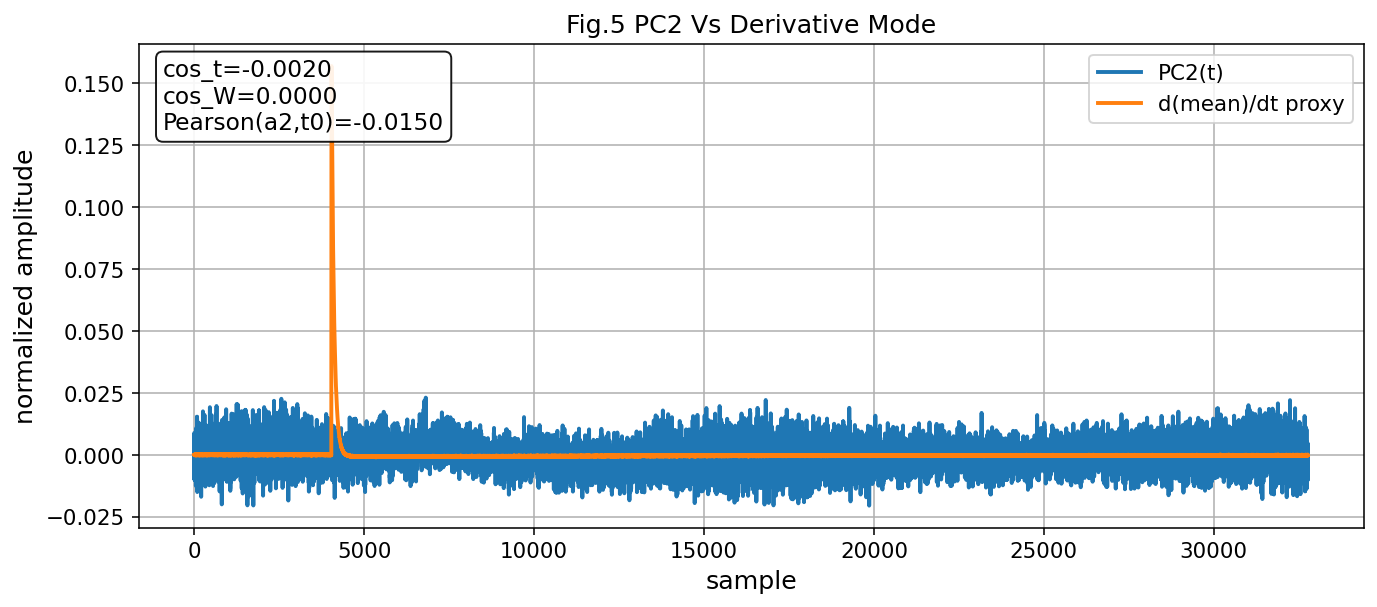

In [13]:
# Figure 5: PC2 vs derivative mode
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(normalize_time(pc2_t), label='PC2(t)')
ax.plot(deriv_t_n, label='d(mean)/dt proxy')
ax.set_title('Fig.5 PC2 Vs Derivative Mode')
ax.set_xlabel('sample')
ax.set_ylabel('normalized amplitude')
ax.legend()

pc2_metrics = {
    'cos_time_pc2_deriv': time_cosine(normalize_time(pc2_t), deriv_t_n),
    'cos_w_pc2_deriv': weighted_cosine(pc2, deriv_f, w_psd),
    'pearson_a2_timing': pearsonr_np(A2, proxy_timing),
    'spearman_a2_timing': spearmanr_np(A2, proxy_timing),
}
ax.text(0.02, 0.97,
        f"cos_t={pc2_metrics['cos_time_pc2_deriv']:.4f}\n"
        f"cos_W={pc2_metrics['cos_w_pc2_deriv']:.4f}\n"
        f"Pearson(a2,t0)={pc2_metrics['pearson_a2_timing']:.4f}",
        transform=ax.transAxes, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

fig.tight_layout()
savefig(fig, 'fig05_pc2_derivative')
plt.show()


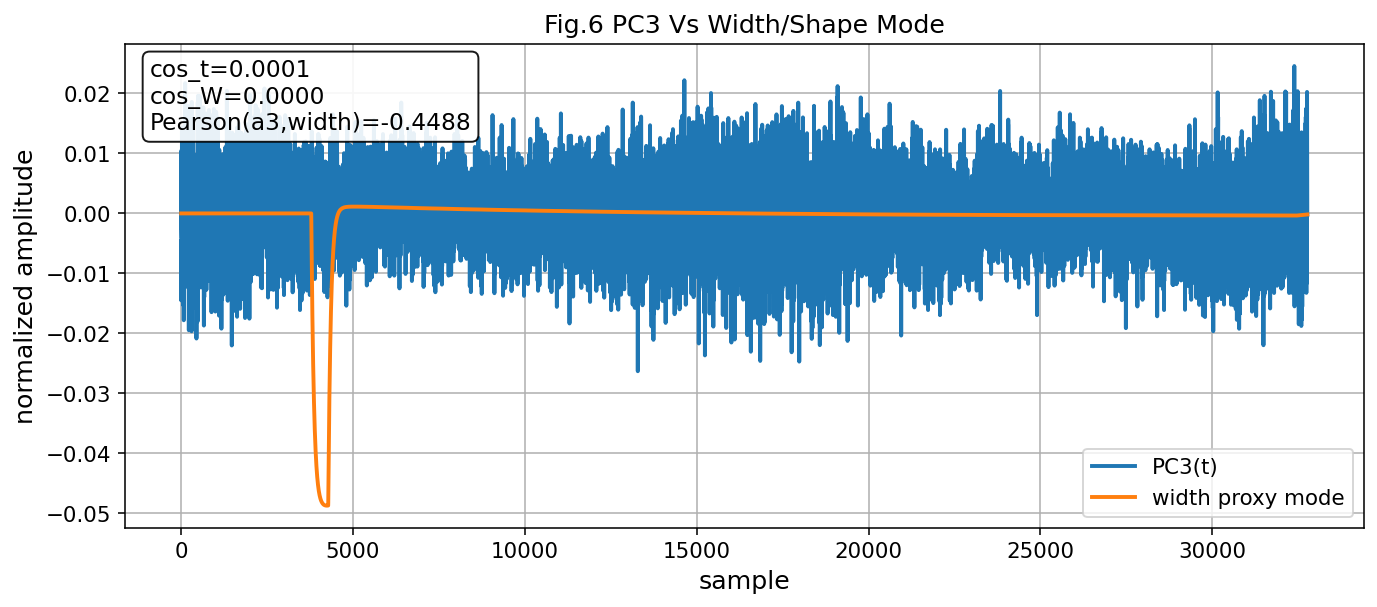

In [14]:
# Figure 6: PC3 vs width/shape mode
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(normalize_time(pc3_t), label='PC3(t)')
ax.plot(width_t_n, label='width proxy mode')
ax.set_title('Fig.6 PC3 Vs Width/Shape Mode')
ax.set_xlabel('sample')
ax.set_ylabel('normalized amplitude')
ax.legend()

pc3_metrics = {
    'cos_time_pc3_width': time_cosine(normalize_time(pc3_t), width_t_n),
    'cos_w_pc3_width': weighted_cosine(pc3, width_proxy_f, w_psd),
    'pearson_a3_width': pearsonr_np(A3, proxy_width),
    'spearman_a3_width': spearmanr_np(A3, proxy_width),
}
ax.text(0.02, 0.97,
        f"cos_t={pc3_metrics['cos_time_pc3_width']:.4f}\n"
        f"cos_W={pc3_metrics['cos_w_pc3_width']:.4f}\n"
        f"Pearson(a3,width)={pc3_metrics['pearson_a3_width']:.4f}",
        transform=ax.transAxes, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

fig.tight_layout()
savefig(fig, 'fig06_pc3_widthmode')
plt.show()


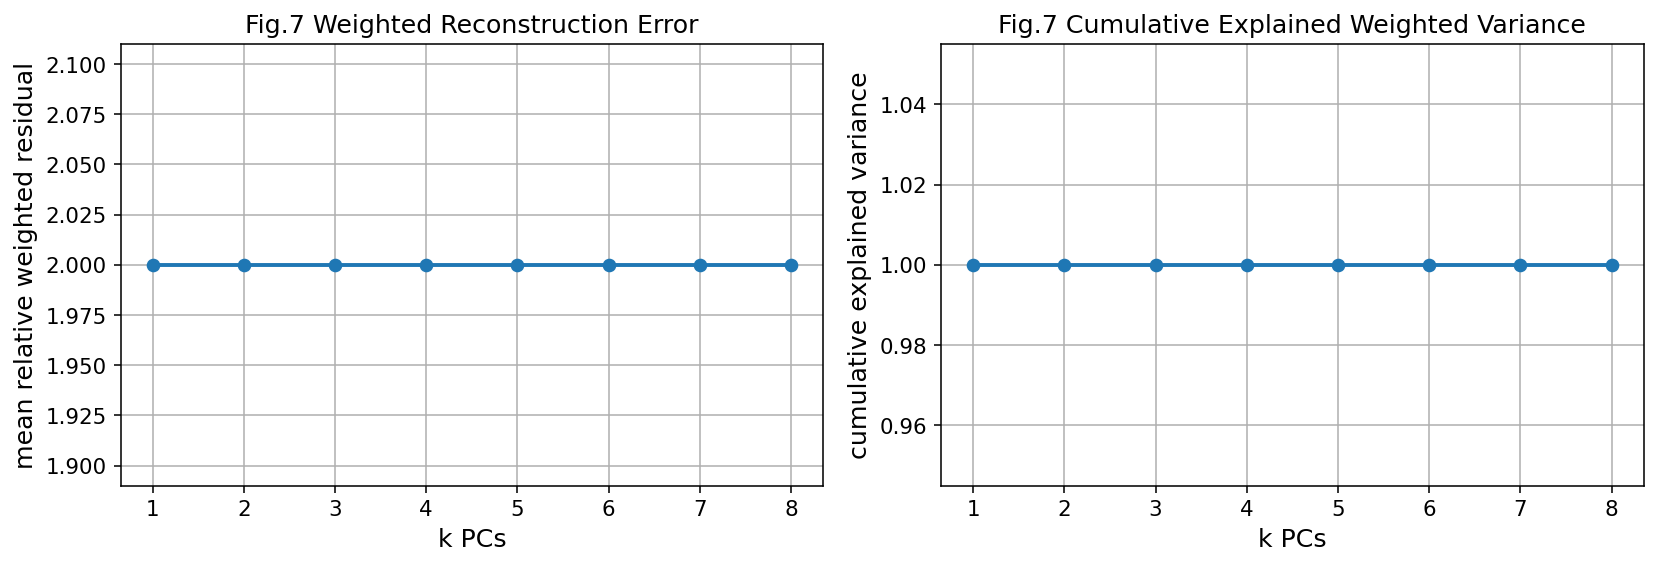

In [15]:

# Figure 7: explained weighted variance and residual reduction
max_k = min(12, pcs_f.shape[0])
rows_ev = []

den = np.sum(np.abs(res_unc['Xw_fit']) ** 2)
for k in range(1, max_k + 1):
    Rk = coeff[:, :k] @ pcs_f[:k]
    rr = weighted_rel_residuals(Xf, Rk, w_psd)
    mse_w = np.mean(rr ** 2)
    cum_expl = float(np.sum(S[:k] ** 2) / np.sum(S ** 2)) if np.sum(S ** 2) > 0 else np.nan
    rows_ev.append((k, float(np.mean(rr)), float(mse_w), cum_expl))

if pd is not None:
    df_ev = pd.DataFrame(rows_ev, columns=['k', 'mean_rel_weighted_resid', 'mean_rel_weighted_resid_sq', 'cum_explained_weighted_var'])
else:
    df_ev = None

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ks = [r[0] for r in rows_ev]
ax[0].plot(ks, [r[1] for r in rows_ev], marker='o')
ax[0].set_title('Fig.7 Weighted Reconstruction Error')
ax[0].set_xlabel('k PCs')
ax[0].set_ylabel('mean relative weighted residual')

ax[1].plot(ks, [r[3] for r in rows_ev], marker='o')
ax[1].set_title('Fig.7 Cumulative Explained Weighted Variance')
ax[1].set_xlabel('k PCs')
ax[1].set_ylabel('cumulative explained variance')

fig.tight_layout()
savefig(fig, 'fig07_explained_variance')
plt.show()


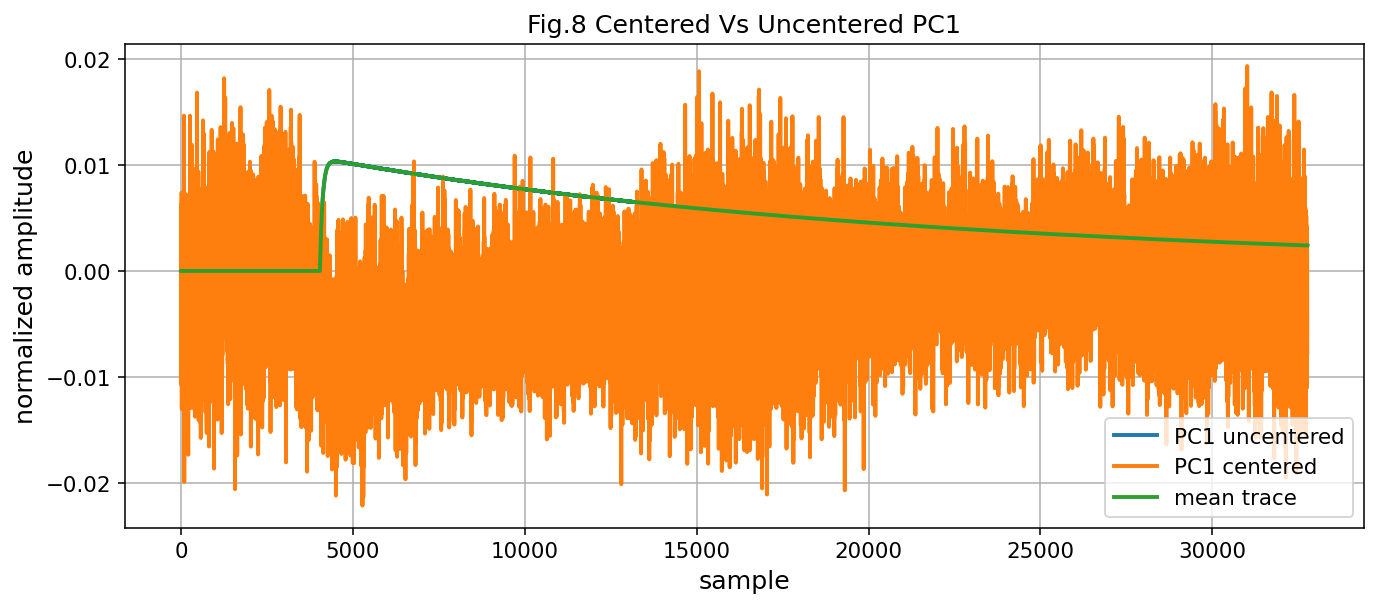

cos_W(PC1_uncentered, mean)= 1.0
cos_W(PC1_centered, mean)= 0.9999999999999999


In [16]:

# Figure 8: centered vs uncentered ablation
pc1_unc = sign_align_to_ref(res_unc['pcs_f'][0], mean_f_ref, w_psd)
pc1_ctr = sign_align_to_ref(res_ctr['pcs_f'][0], mean_f_ref, w_psd)

pc1_unc_t = to_time(pc1_unc, n_time=n_time)[0]
pc1_ctr_t = to_time(pc1_ctr, n_time=n_time)[0]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(normalize_time(pc1_unc_t), label='PC1 uncentered')
ax.plot(normalize_time(pc1_ctr_t), label='PC1 centered')
ax.plot(normalize_time(mean_time), label='mean trace')
ax.set_title('Fig.8 Centered Vs Uncentered PC1')
ax.set_xlabel('sample')
ax.set_ylabel('normalized amplitude')
ax.legend()
fig.tight_layout()
savefig(fig, 'fig08_centering_ablation')
plt.show()

print('cos_W(PC1_uncentered, mean)=', weighted_cosine(pc1_unc, mean_f_ref, w_psd))
print('cos_W(PC1_centered, mean)=', weighted_cosine(pc1_ctr, mean_f_ref, w_psd))


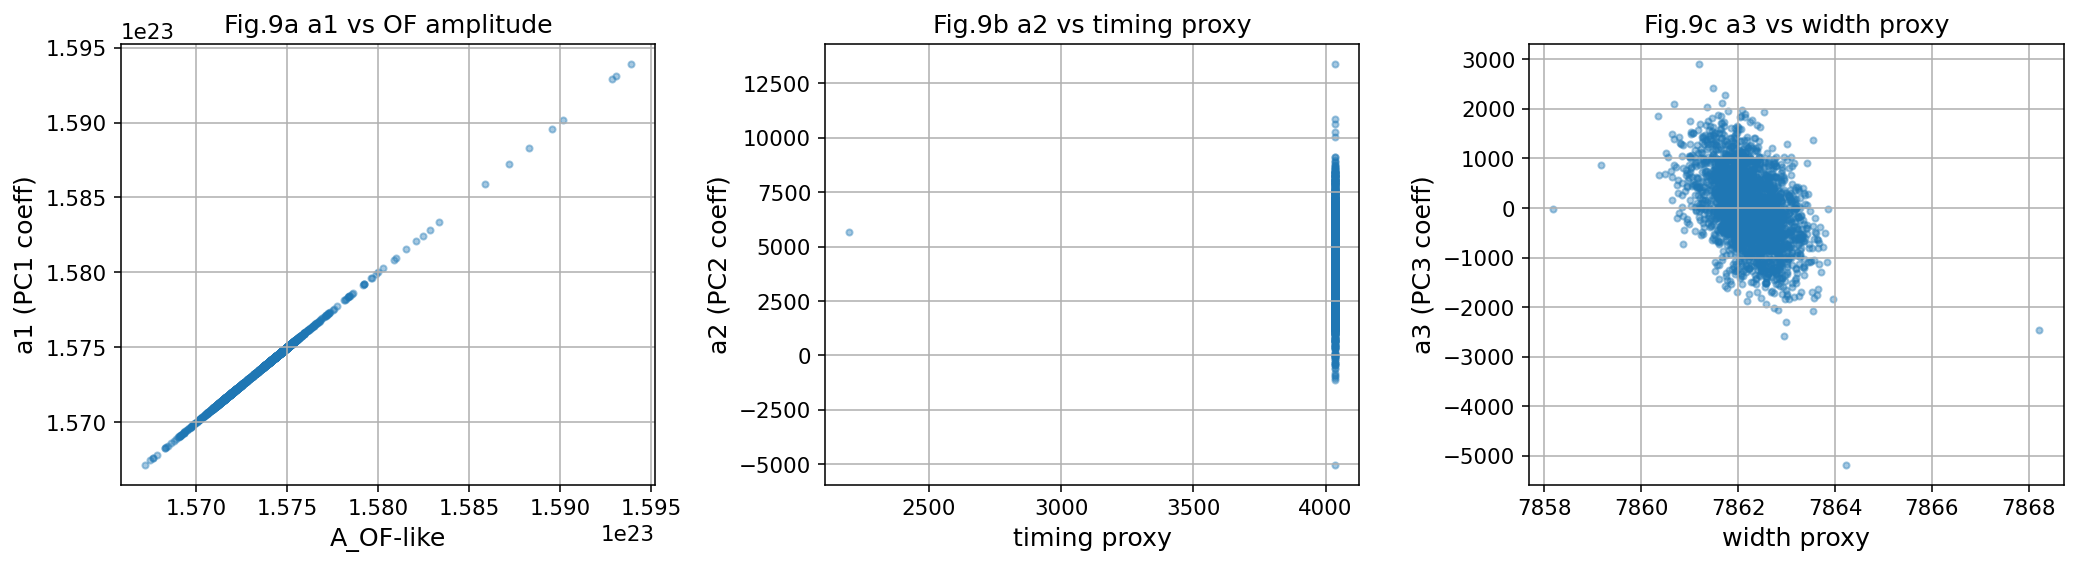

In [17]:

# Figure 9: coefficient interpretation scatter plots
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

ax[0].scatter(A_of, A1, s=10, alpha=0.4)
ax[0].set_title('Fig.9a a1 vs OF amplitude')
ax[0].set_xlabel('A_OF-like')
ax[0].set_ylabel('a1 (PC1 coeff)')

ax[1].scatter(proxy_timing, A2, s=10, alpha=0.4)
ax[1].set_title('Fig.9b a2 vs timing proxy')
ax[1].set_xlabel('timing proxy')
ax[1].set_ylabel('a2 (PC2 coeff)')

ax[2].scatter(proxy_width, A3, s=10, alpha=0.4)
ax[2].set_title('Fig.9c a3 vs width proxy')
ax[2].set_xlabel('width proxy')
ax[2].set_ylabel('a3 (PC3 coeff)')

fig.tight_layout()
savefig(fig, 'fig09_coeff_scatter')
plt.show()


In [18]:

# Summary metrics table + coefficient correlation table
pairs = [
    ('a1_vs_of', A1, A_of),
    ('a2_vs_timing', A2, proxy_timing),
    ('a3_vs_width', A3, proxy_width),
]

corr_rows = []
for name, x, y in pairs:
    fit = linear_fit_metrics(x, y)
    corr_rows.append({
        'pair': name,
        'pearson': pearsonr_np(x, y),
        'spearman': spearmanr_np(x, y),
        'slope': fit['slope'],
        'intercept': fit['intercept'],
        'r2': fit['r2'],
    })

summary_rows = [
    {'metric': 'cos_t(PC1,mean)', 'value': metrics_pc1['cos_time_pc1_mean']},
    {'metric': 'cos_t(PC1,template)', 'value': metrics_pc1['cos_time_pc1_template']},
    {'metric': 'cos_t(PC1,T/PSD-like)', 'value': metrics_pc1['cos_time_pc1_of_like']},
    {'metric': 'cos_W(PC1,mean)', 'value': metrics_pc1['cos_w_pc1_mean']},
    {'metric': 'cos_W(PC1,T/PSD-like)', 'value': metrics_pc1['cos_w_pc1_of_like']},
    {'metric': 'cos_t(PC2,derivative)', 'value': pc2_metrics['cos_time_pc2_deriv']},
    {'metric': 'cos_W(PC2,derivative)', 'value': pc2_metrics['cos_w_pc2_deriv']},
    {'metric': 'cos_t(PC3,width)', 'value': pc3_metrics['cos_time_pc3_width']},
    {'metric': 'cos_W(PC3,width)', 'value': pc3_metrics['cos_w_pc3_width']},
    {'metric': 'pearson(a2,timing)', 'value': pc2_metrics['pearson_a2_timing']},
    {'metric': 'pearson(a3,width)', 'value': pc3_metrics['pearson_a3_width']},
    {'metric': 'mean_rel_weighted_resid_k1', 'value': rows_ev[0][1]},
    {'metric': 'mean_rel_weighted_resid_k2', 'value': rows_ev[1][1]},
    {'metric': 'mean_rel_weighted_resid_k3', 'value': rows_ev[2][1]},
]

if pd is not None:
    summary_df = pd.DataFrame(summary_rows)
    corr_df = pd.DataFrame(corr_rows)
    summary_df.to_csv(TAB_DIR / 'empca_summary_metrics.csv', index=False)
    corr_df.to_csv(TAB_DIR / 'coeff_correlations.csv', index=False)
    if df_ev is not None:
        df_ev.to_csv(TAB_DIR / 'explained_variance_metrics.csv', index=False)

    display(summary_df)
    display(corr_df)
else:
    print(summary_rows)
    print(corr_rows)


,metric,value
0,"cos_t(PC1,mean)",9.999993e-01
1,"cos_t(PC1,template)",9.997018e-01
2,"cos_t(PC1,T/PSD-like)",8.629808e-01
3,"cos_W(PC1,mean)",1.000000e+00
4,"cos_W(PC1,T/PSD-like)",1.000000e+00
5,"cos_t(PC2,derivative)",-1.972861e-03
6,"cos_W(PC2,derivative)",5.471427e-16
7,"cos_t(PC3,width)",1.400251e-04
8,"cos_W(PC3,width)",6.487424e-17
9,"pearson(a2,timing)",-1.495848e-02


,pair,pearson,spearman,slope,intercept,r2
0,a1_vs_of,1.000000,1.000000,0.999984,2.506195e+18,1.000000
1,a2_vs_timing,-0.014958,-0.049286,-0.000304,4.035483e+03,0.000224
2,a3_vs_width,-0.448814,-0.441483,-0.000353,7.862217e+03,0.201434


### Optional Synthetic Validation Block

In [19]:

if CFG['run_toy_validation']:
    rng = np.random.default_rng(CFG['rng_seed'] + 123)

    def shift_waveform(x, dt):
        t = np.arange(len(x))
        return np.interp(t - dt, t, x, left=x[0], right=x[-1])

    def add_noise_freq(xf, psd_vec, rng_local):
        n = len(xf)
        z = (rng_local.normal(size=n) + 1j * rng_local.normal(size=n)) * np.sqrt(psd_vec / 2.0)
        z[0] = np.real(z[0])
        if n > 1:
            z[-1] = np.real(z[-1])
        return xf + z

    def build_toy(n_events=1200):
        Xtoy = []
        for _ in range(n_events):
            A = 1.0 + 0.09 * rng.normal()
            t0 = 1.8 * rng.normal()
            e = 0.025 * rng.normal()
            s = A * deform_stretch(shift_waveform(mean_time, t0), 1.0 + e)
            sf = to_freq(s)[0]
            Xtoy.append(add_noise_freq(sf, psd, rng))
        return np.asarray(Xtoy)

    Xtoy = build_toy(CFG['toy_n_events'])
    toy = train_clean_empca_weighted(Xtoy, w_psd, n_components=3, center=False)
    tp1, tp2, tp3 = toy['pcs_f'][:3]
    tp1 = sign_align_to_ref(tp1, normalize_weighted(to_freq(mean_time)[0], w_psd), w_psd)
    tp2 = sign_align_to_ref(tp2, deriv_f, w_psd)
    tp3 = sign_align_to_ref(tp3, width_proxy_f, w_psd)

    print('Toy cos_W(PC1,signal)=', weighted_cosine(tp1, normalize_weighted(to_freq(mean_time)[0], w_psd), w_psd))
    print('Toy cos_W(PC2,derivative)=', weighted_cosine(tp2, deriv_f, w_psd))
    print('Toy cos_W(PC3,width)=', weighted_cosine(tp3, width_proxy_f, w_psd))


Toy cos_W(PC1,signal)= 1.0000000000000002
Toy cos_W(PC2,derivative)= 4.963027913323574e-16
Toy cos_W(PC3,width)= 3.1956032056587484e-17



## Section E - Interpretation

Conservative interpretation supported by the metrics and figures:

1. EMPCA training is performed in weighted frequency space with PSD-based metric.
2. In uncentered training, PC1 aligns strongly with the empirical mean pulse direction and resembles the template in time domain.
3. PC2 is consistent with a timing-jitter derivative mode (overlap with $s'(t)$ and coefficient/timing correlation).
4. PC3 is consistent with a higher-order shape deformation mode, captured here by a width perturbation proxy.
5. Centering materially changes leading-mode interpretation, as shown by the centered-vs-uncentered ablation.

Note: rank-1 EMPCA and OF-like amplitude can be strongly related, but PC1 is not asserted to be exactly $T/\mathrm{PSD}$ unless assumptions and normalization are matched.


In [20]:

# Notebook artifact copy for requested output layout
import shutil
this_nb = Path('wk8/PC_interpretation/clean_empca_kalpha_frequency_training_paperready.ipynb')
if this_nb.exists():
    shutil.copy2(this_nb, NB_DIR / this_nb.name)
print('Notebook copy saved to', NB_DIR / this_nb.name)
print('Figures saved in', FIG_DIR)
print('Tables saved in', TAB_DIR)


Notebook copy saved to /home/dwong/DELight_mtr/PCA_dev/outputs/notebook/clean_empca_kalpha_frequency_training_paperready.ipynb
Figures saved in /home/dwong/DELight_mtr/PCA_dev/outputs/figures
Tables saved in /home/dwong/DELight_mtr/PCA_dev/outputs/tables
